# Track A — 발표용 그래프 생성 (track_a_04)

담당: 김태헌 | 입력: track_a_01~03 결과 CSV/JSON

## 이 노트북이 하는 일

track_a_01~03의 저장 결과를 읽어서 발표 슬라이드용 그래프 3개를 PNG로 저장한다.
track_b_13과 동일한 스타일(네이비 `#1F4E79`, 맑은 고딕)을 사용한다.

1. 3단 비교 (CB 완전정보 → A1 → A2, F0/F1/F2 민감도 포함)
2. A2 변수 중요도 (track_a_02)
3. 씬파일러 등급 분포 — 엄격 vs 비엄격 (track_a_03)

## 0. 환경 설정

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

handoff_path = r'C:\Users\tehun\Desktop\multicamp\project\creditscore\personalCB'
output_dir = os.path.join(handoff_path, '발표자료')
os.makedirs(output_dir, exist_ok=True)

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

NAVY, NAVY_LIGHT, ACCENT, GRAY = '#1F4E79', '#D9E1F2', '#C00000', '#595959'

def save_fig(fig, name):
    path = os.path.join(output_dir, f'{name}.png')
    fig.savefig(path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"저장: {path}")


## 1. 3단 비교 — CB 완전정보 → A1 → A2 (F0/F1/F2)

`track_a_model_comparison_final.csv`(track_a_01 산출)를 읽어서 정보량이 줄어들수록
AUROC가 어떻게 변하는지 보여주는 막대그래프.

저장: C:\Users\tehun\Desktop\multicamp\project\creditscore\personalCB\발표자료\01_3단비교_A1A2.png


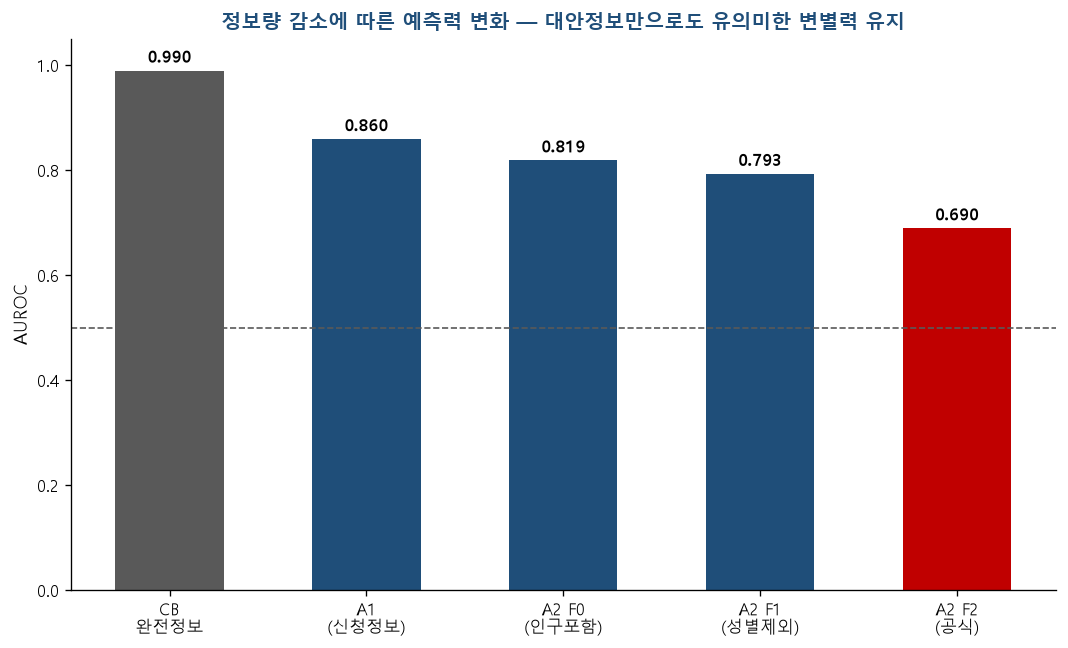

In [2]:
df_comp = pd.read_csv(f'{handoff_path}/track_a_model_comparison_final.csv')

fig, ax = plt.subplots(figsize=(9, 5.5))
colors = [GRAY if 'CB' in m else (ACCENT if '공식' in m else NAVY) for m in df_comp['모델']]
bars = ax.bar(range(len(df_comp)), df_comp['AUROC'], color=colors, width=0.55)

for b, v in zip(bars, df_comp['AUROC']):
    ax.text(b.get_x()+b.get_width()/2, v+0.015, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(range(len(df_comp)))
ax.set_xticklabels(['CB\n완전정보', 'A1\n(신청정보)', 'A2 F0\n(인구포함)', 'A2 F1\n(성별제외)', 'A2 F2\n(공식)'],
                    fontsize=10)
ax.axhline(0.5, color=GRAY, linestyle='--', linewidth=1)
ax.set_ylabel('AUROC', fontsize=11)
ax.set_title('정보량 감소에 따른 예측력 변화 — 대안정보만으로도 유의미한 변별력 유지',
             fontsize=12, fontweight='bold', color=NAVY)
ax.set_ylim(0, 1.05)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
save_fig(fig, '01_3단비교_A1A2')
plt.show()


## 2. A2 변수 중요도 (track_a_02)

저장: C:\Users\tehun\Desktop\multicamp\project\creditscore\personalCB\발표자료\02_A2_변수중요도.png


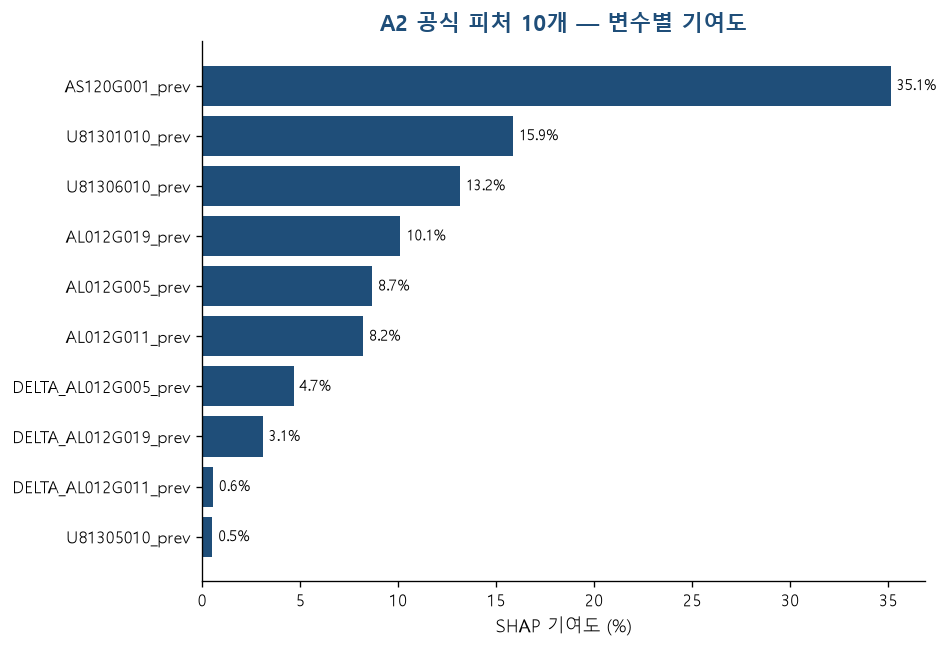

In [3]:
imp = pd.read_csv(f'{handoff_path}/track_a_shap_importance.csv', index_col=0).iloc[:,0]

fig, ax = plt.subplots(figsize=(8, 5.5))
bars = ax.barh(imp.index[::-1], imp.values[::-1], color=NAVY)
for b, v in zip(bars, imp.values[::-1]):
    ax.text(v+0.3, b.get_y()+b.get_height()/2, f'{v:.1f}%', va='center', fontsize=9)
ax.set_xlabel('SHAP 기여도 (%)', fontsize=11)
ax.set_title('A2 공식 피처 10개 — 변수별 기여도', fontsize=13, fontweight='bold', color=NAVY)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
save_fig(fig, '02_A2_변수중요도')
plt.show()


## 3. 씬파일러 등급 분포 — 엄격 vs 비엄격 (track_a_03)

저장: C:\Users\tehun\Desktop\multicamp\project\creditscore\personalCB\발표자료\03_엄격비엄격_등급분포.png


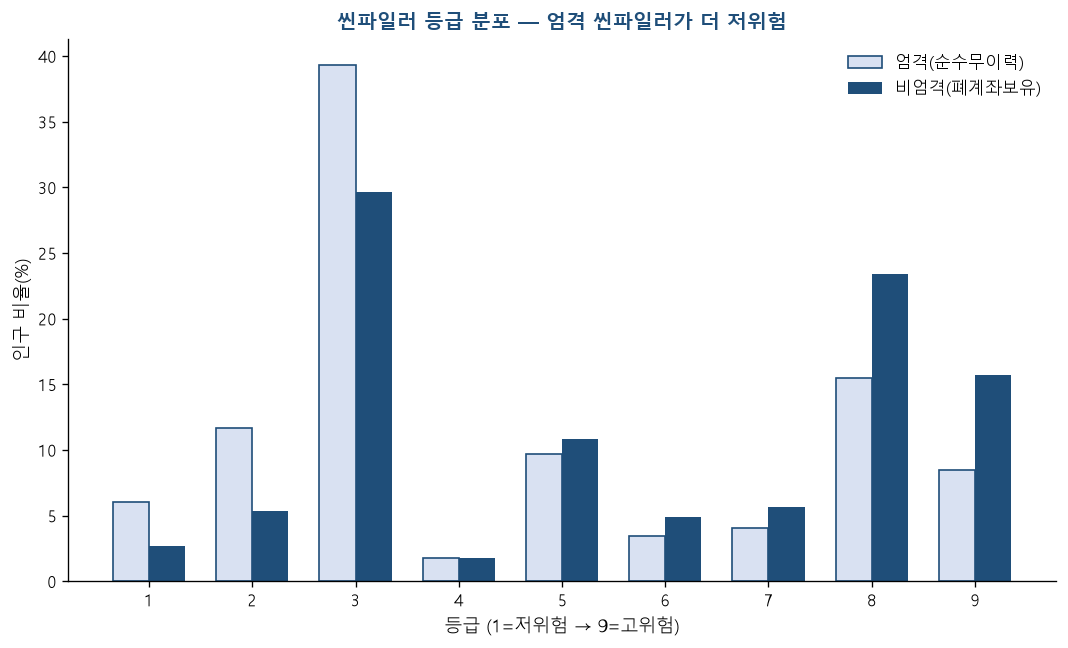

In [4]:
df_grades = pd.read_csv(f'{handoff_path}/track_a_apply_grades.csv')

strict_dist = (df_grades[df_grades['IS_STRICT']]['grade'].value_counts(normalize=True).sort_index()*100).reindex(range(1,10), fill_value=0)
nonstrict_dist = (df_grades[~df_grades['IS_STRICT']]['grade'].value_counts(normalize=True).sort_index()*100).reindex(range(1,10), fill_value=0)

fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(1, 10)
width = 0.35
ax.bar(x - width/2, strict_dist.values, width, label='엄격(순수무이력)', color=NAVY_LIGHT, edgecolor=NAVY)
ax.bar(x + width/2, nonstrict_dist.values, width, label='비엄격(폐계좌보유)', color=NAVY)
ax.set_xticks(x)
ax.set_xlabel('등급 (1=저위험 → 9=고위험)', fontsize=11)
ax.set_ylabel('인구 비율(%)', fontsize=11)
ax.set_title('씬파일러 등급 분포 — 엄격 씬파일러가 더 저위험', fontsize=12, fontweight='bold', color=NAVY)
ax.legend(frameon=False)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
save_fig(fig, '03_엄격비엄격_등급분포')
plt.show()


## 완료

`{handoff_path}/발표자료/` 폴더에 3개 PNG(300dpi)가 저장됐다.